<a href="https://colab.research.google.com/github/Prajkta11222/Smart-Vehical-Health-Intelligence-and-Predictive-Maintenance-Recommendation-System/blob/main/Vehicle_Health_Model_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Devlopment of a smart Vehical Health Intelligence and Predictive Maintenance Recommendation System


In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Smart_Vehicle_Health_Project/dataset/vehicle_maintenance_data.csv')

In [4]:
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


In [5]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(50000, 20)


In [6]:
print(df.columns.tolist())

['Vehicle_Model', 'Mileage', 'Maintenance_History', 'Reported_Issues', 'Vehicle_Age', 'Fuel_Type', 'Transmission_Type', 'Engine_Size', 'Odometer_Reading', 'Last_Service_Date', 'Warranty_Expiry_Date', 'Owner_Type', 'Insurance_Premium', 'Service_History', 'Accident_History', 'Fuel_Efficiency', 'Tire_Condition', 'Brake_Condition', 'Battery_Status', 'Need_Maintenance']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

In [8]:
df.isnull().sum()

,0
Vehicle_Model,0
Mileage,0
Maintenance_History,0
Reported_Issues,0
Vehicle_Age,0
Fuel_Type,0
Transmission_Type,0
Engine_Size,0
Odometer_Reading,0
Last_Service_Date,0


In [9]:
print(df.duplicated().sum())

0


In [10]:
df["Need_Maintenance"].value_counts()

,count
Need_Maintenance,
1,40498
0,9502


In [11]:
(
    df["Need_Maintenance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
Need_Maintenance,
1,81.0
0,19.0


#Exploratory Data Analysis (EDA)

In [12]:
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 20)


In [13]:
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


In [14]:
df.tail()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
49995,Car,77229,Good,3,6,Diesel,Automatic,2500,97404,2023-11-24,2025-09-15,Third,5217,4,1,10.357298,New,Good,Weak,1
49996,Truck,54742,Good,4,4,Diesel,Manual,800,13421,2023-07-14,2025-01-21,Second,15856,4,1,14.924022,Worn Out,New,Good,1
49997,Van,75601,Poor,0,4,Electric,Automatic,1500,124851,2023-09-09,2024-11-09,First,6019,10,0,19.859243,Worn Out,Worn Out,Weak,1
49998,Car,66181,Good,1,7,Electric,Manual,2500,103182,2023-08-26,2025-05-22,Third,5030,4,3,10.720555,New,Good,Weak,1
49999,Car,71605,Poor,0,10,Petrol,Manual,2000,65721,2023-07-25,2024-06-06,Third,9171,6,3,16.328945,Good,New,Good,0


In [15]:
print(df.columns.tolist())

['Vehicle_Model', 'Mileage', 'Maintenance_History', 'Reported_Issues', 'Vehicle_Age', 'Fuel_Type', 'Transmission_Type', 'Engine_Size', 'Odometer_Reading', 'Last_Service_Date', 'Warranty_Expiry_Date', 'Owner_Type', 'Insurance_Premium', 'Service_History', 'Accident_History', 'Fuel_Efficiency', 'Tire_Condition', 'Brake_Condition', 'Battery_Status', 'Need_Maintenance']


In [16]:
df.dtypes

,0
Vehicle_Model,object
Mileage,int64
Maintenance_History,object
Reported_Issues,int64
Vehicle_Age,int64
Fuel_Type,object
Transmission_Type,object
Engine_Size,int64
Odometer_Reading,int64
Last_Service_Date,object


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

In [18]:
missing = df.isnull().sum()

print(missing)

Vehicle_Model           0
Mileage                 0
Maintenance_History     0
Reported_Issues         0
Vehicle_Age             0
Fuel_Type               0
Transmission_Type       0
Engine_Size             0
Odometer_Reading        0
Last_Service_Date       0
Warranty_Expiry_Date    0
Owner_Type              0
Insurance_Premium       0
Service_History         0
Accident_History        0
Fuel_Efficiency         0
Tire_Condition          0
Brake_Condition         0
Battery_Status          0
Need_Maintenance        0
dtype: int64


In [19]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [20]:
df.describe()

,Mileage,Reported_Issues,Vehicle_Age,Engine_Size,Odometer_Reading,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Need_Maintenance
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,54931.232680,2.497420,5.492260,1556.292000,75551.187060,17465.340700,5.515560,1.50156,14.990323,0.809960
std,14401.912925,1.708781,2.875682,627.677218,43088.105658,7223.393401,2.874899,1.11951,2.885583,0.392336
min,30001.000000,0.000000,1.000000,800.000000,1001.000000,5000.000000,1.000000,0.00000,10.000098,0.000000
25%,42471.500000,1.000000,3.000000,1000.000000,38009.000000,11189.750000,3.000000,0.00000,12.489037,1.000000
50%,54810.000000,2.000000,5.000000,1500.000000,75598.500000,17477.500000,6.000000,2.00000,14.986352,1.000000
75%,67391.500000,4.000000,8.000000,2000.000000,112999.500000,23692.000000,8.000000,3.00000,17.474676,1.000000
max,80000.000000,5.000000,10.000000,2500.000000,149999.000000,30000.000000,10.000000,3.00000,19.999968,1.000000


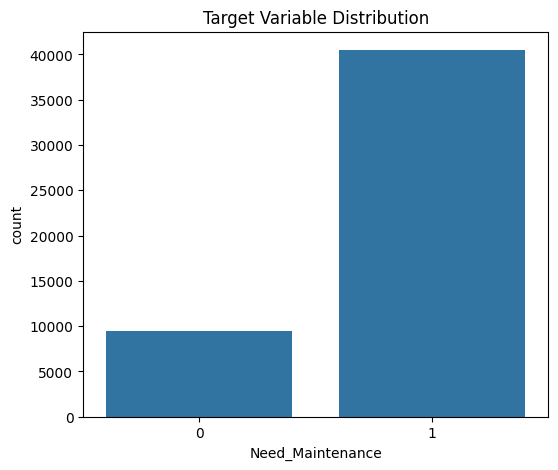

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Need_Maintenance",
    data=df
)

plt.title("Target Variable Distribution")

plt.show()

In [22]:
(
df["Need_Maintenance"]
.value_counts(normalize=True)
.mul(100)
.round(2)
)

,proportion
Need_Maintenance,
1,81.0
0,19.0


In [23]:
numerical_columns = [

"Mileage",

"Reported_Issues",

"Vehicle_Age",

"Engine_Size",

"Odometer_Reading",

"Insurance_Premium",

"Service_History",

"Accident_History",

"Fuel_Efficiency"

]

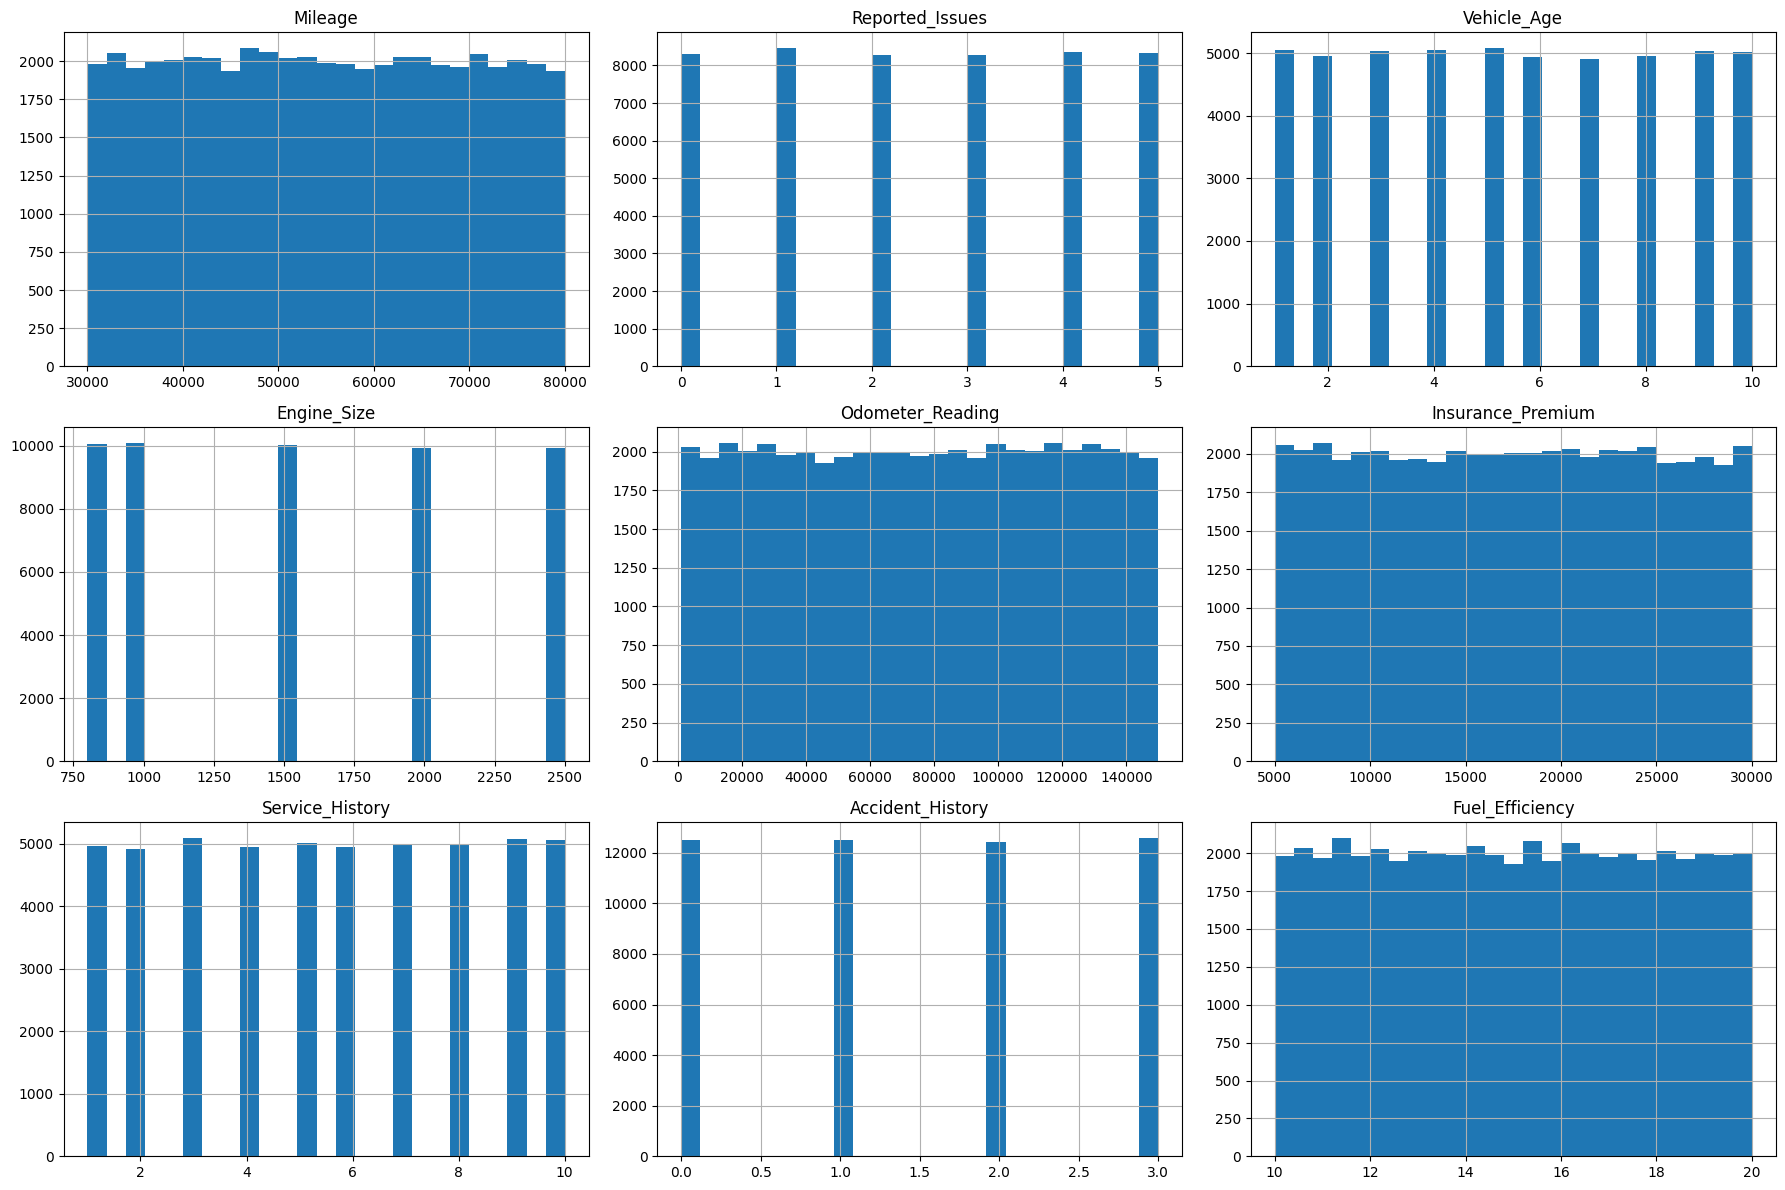

In [24]:
df[numerical_columns].hist(

figsize=(18,12),

bins=25

)

plt.tight_layout()

plt.show()

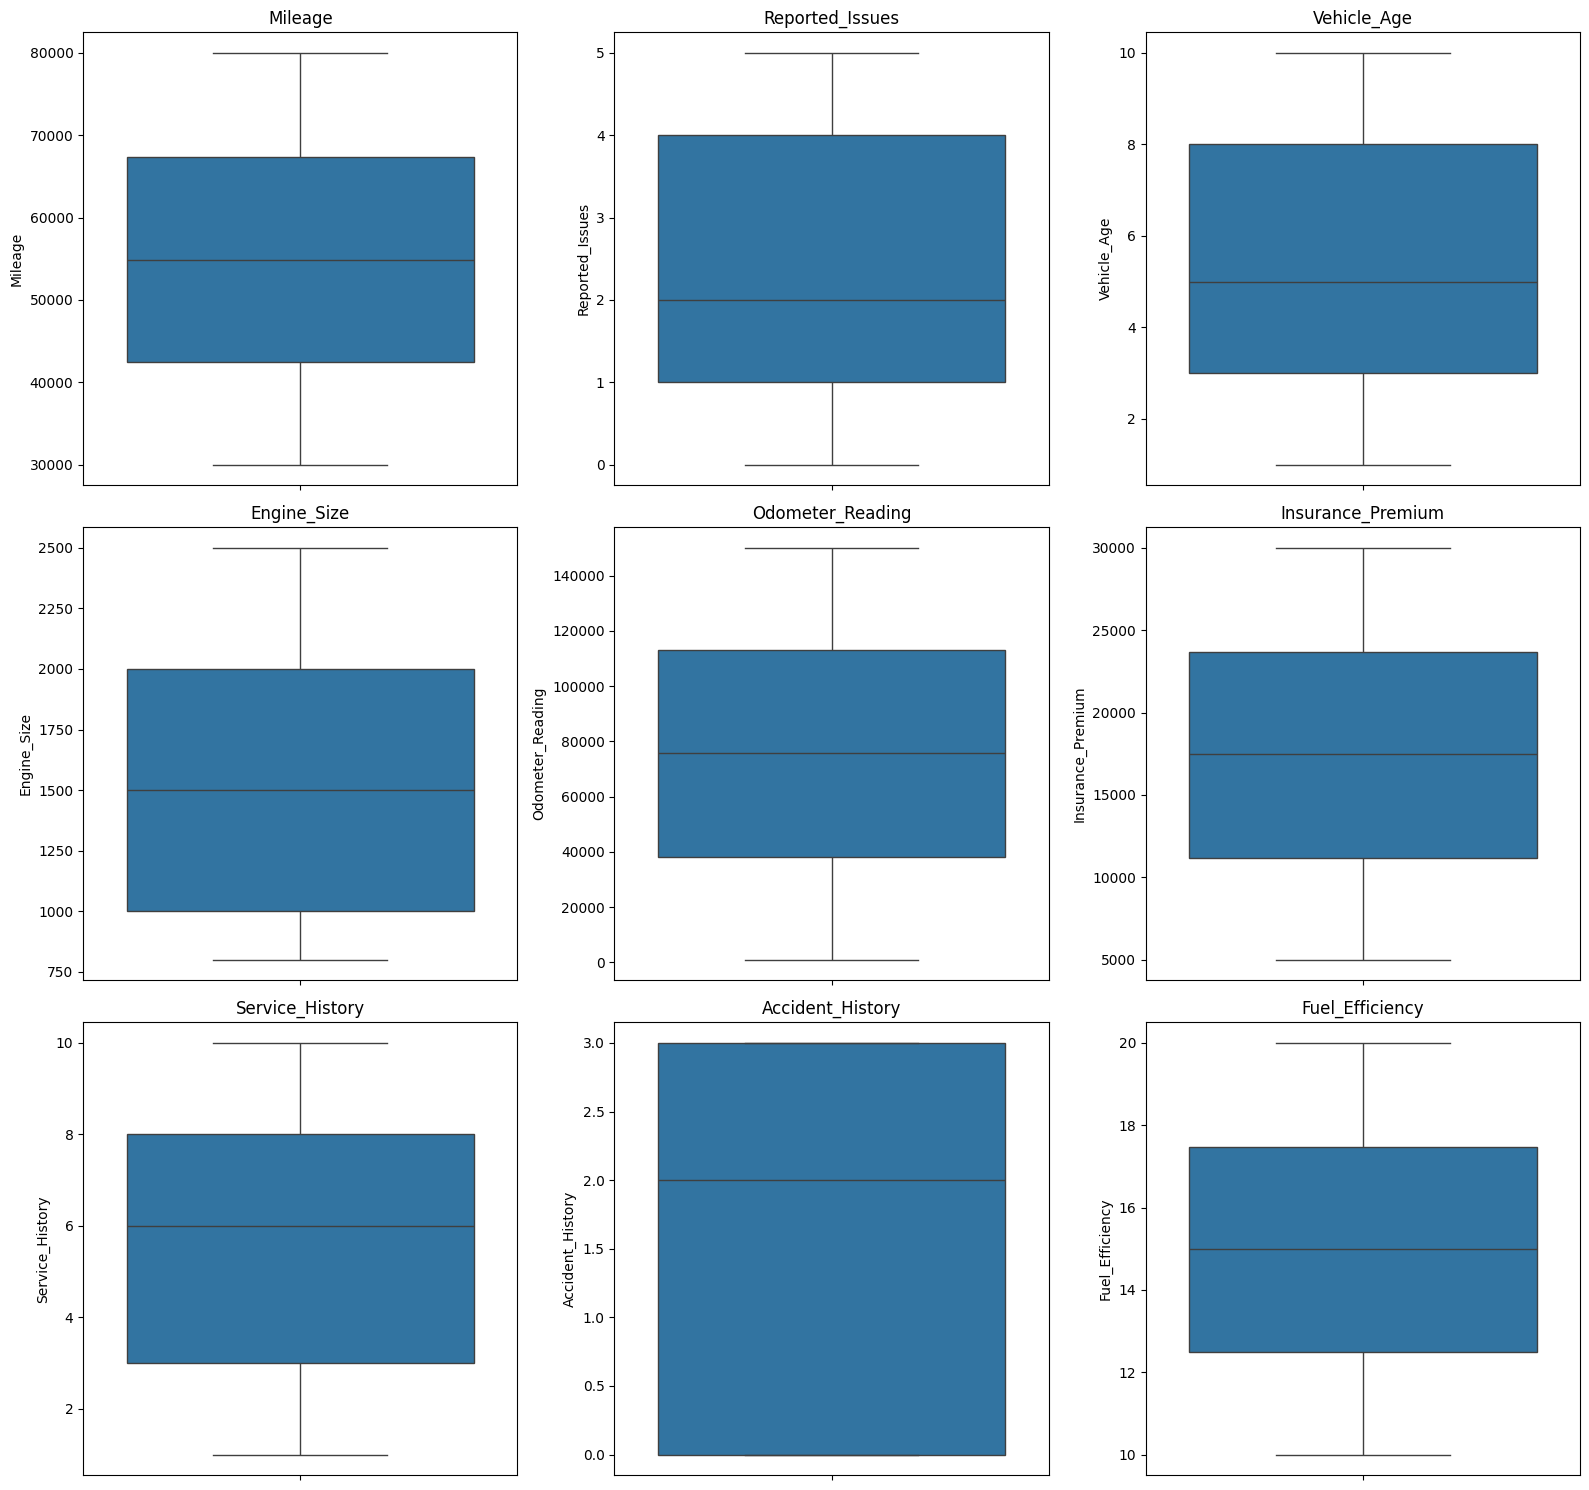

In [25]:
import math

cols = 3

rows = math.ceil(len(numerical_columns)/cols)

plt.figure(figsize=(16,5*rows))

for i,column in enumerate(numerical_columns):

    plt.subplot(rows,cols,i+1)

    sns.boxplot(y=df[column])

    plt.title(column)

plt.tight_layout()

plt.show()

In [26]:
categorical_columns=[

"Vehicle_Model",

"Maintenance_History",

"Fuel_Type",

"Transmission_Type",

"Owner_Type",

"Tire_Condition",

"Brake_Condition",

"Battery_Status"

]

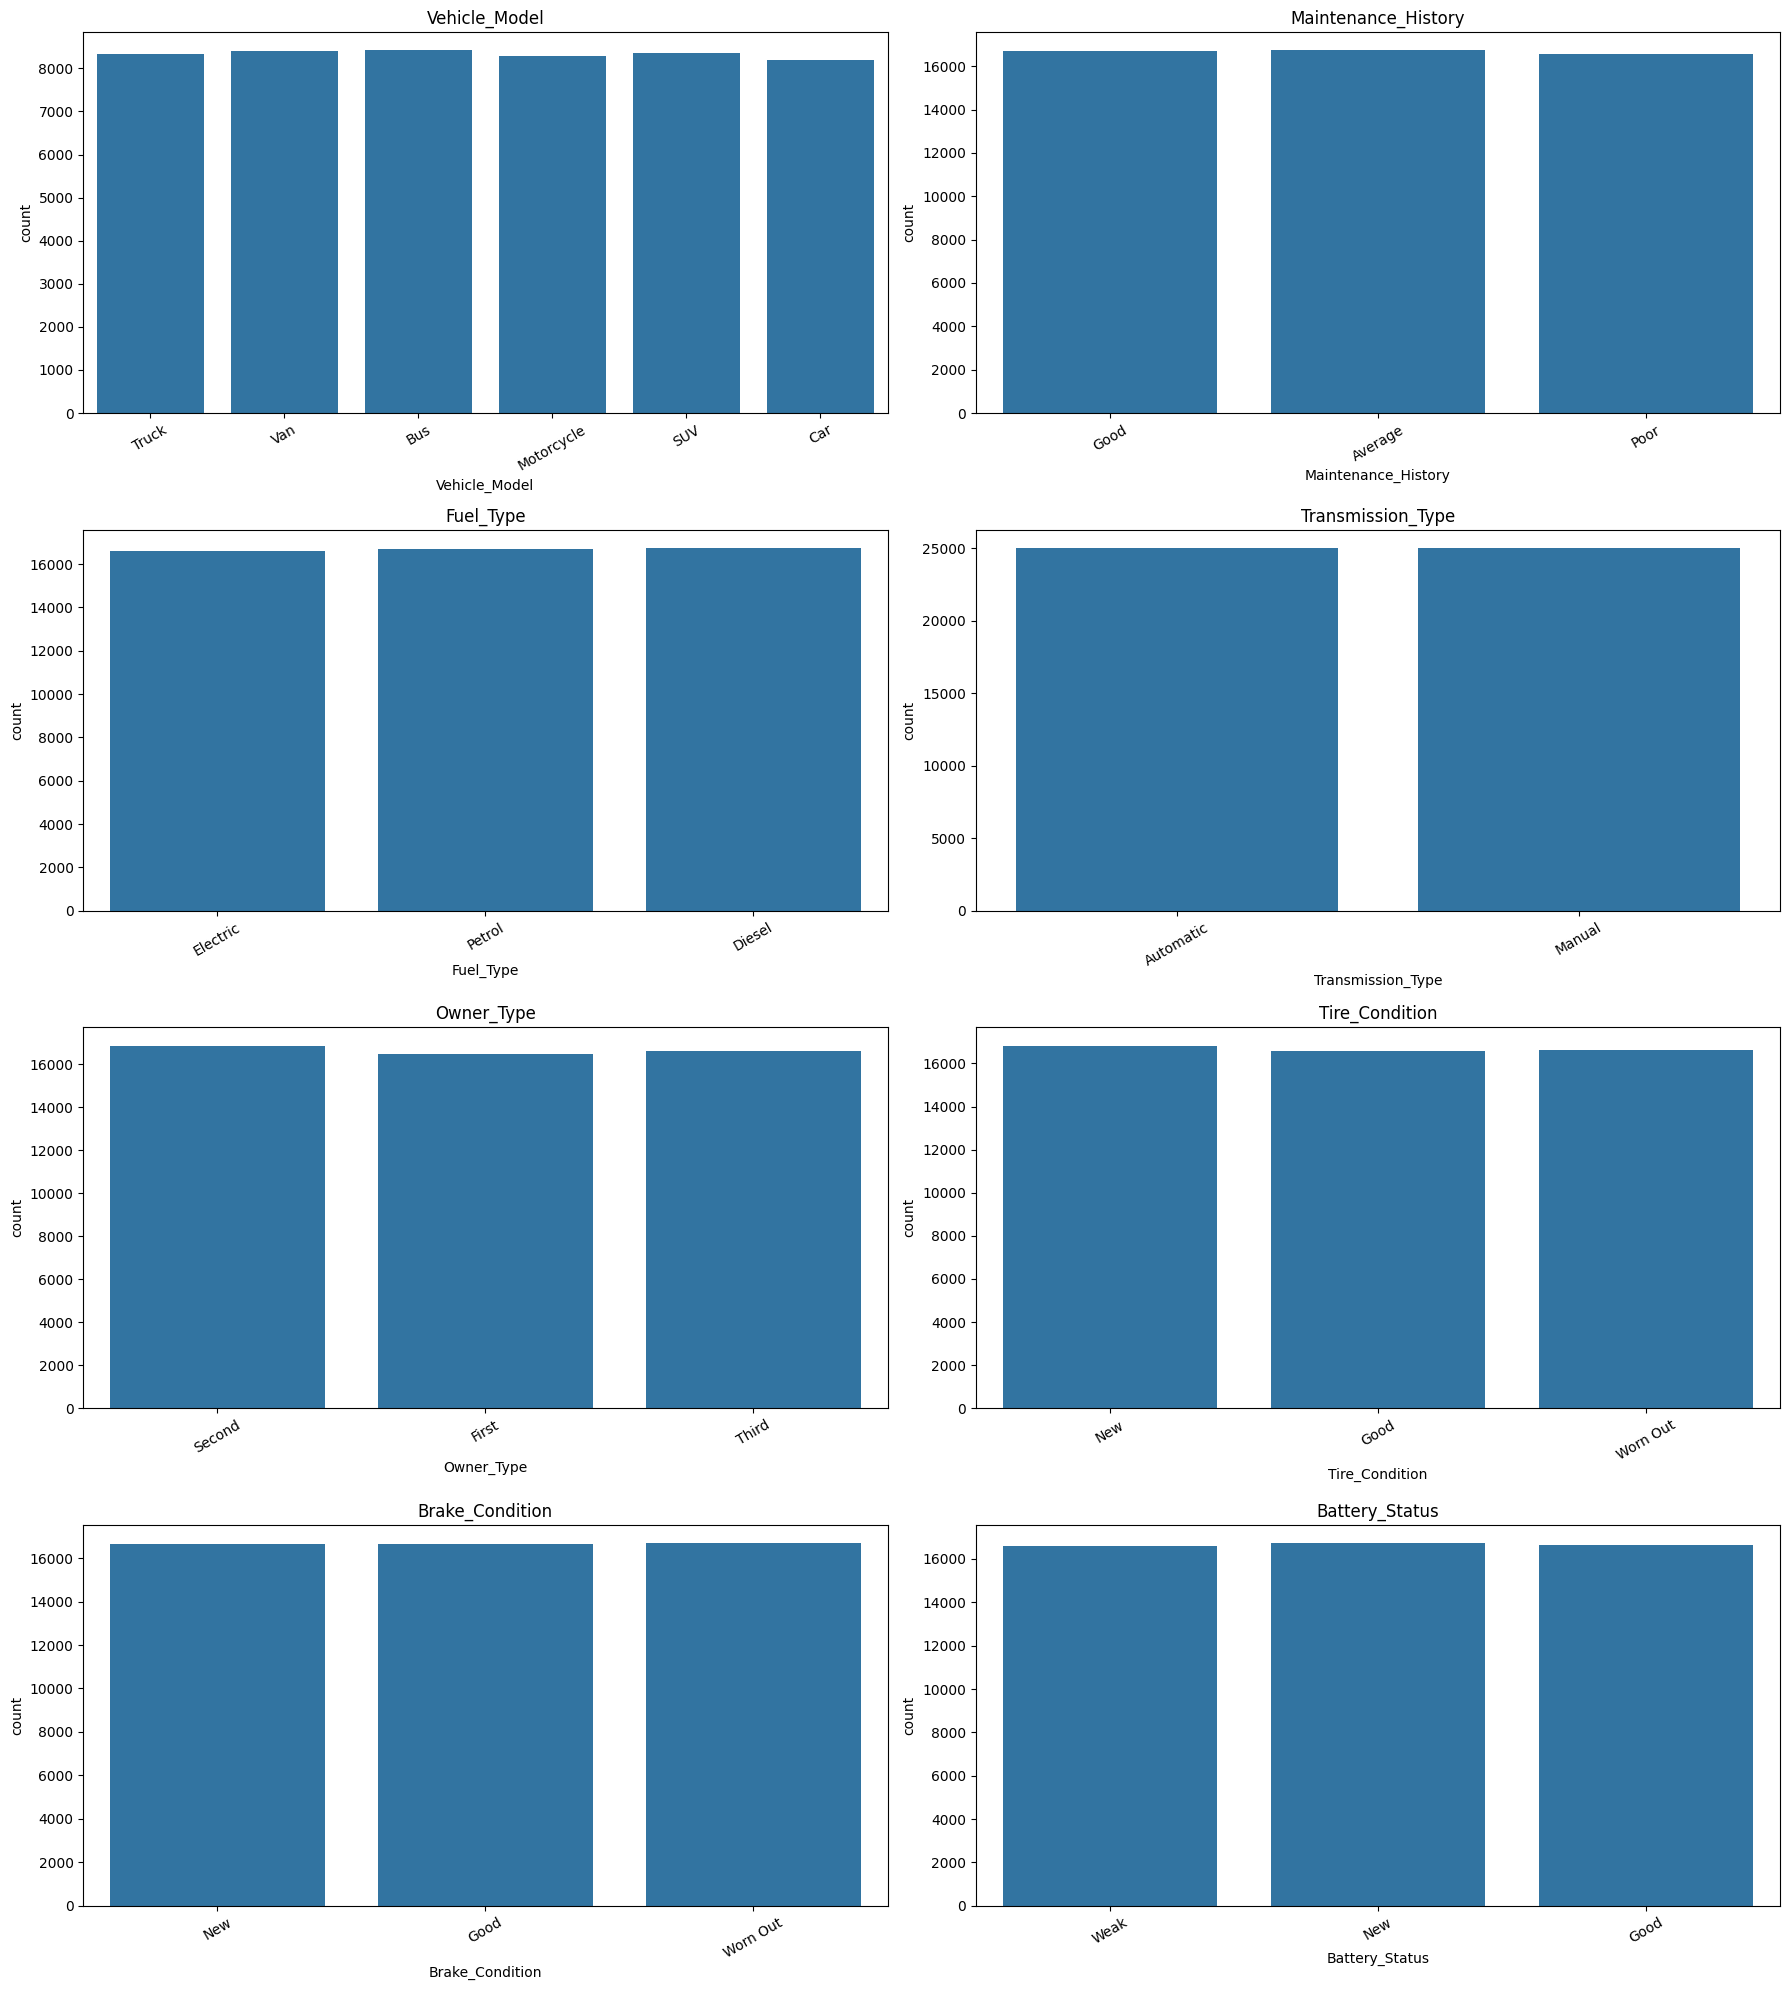

In [27]:
plt.figure(figsize=(18,20))

for i,column in enumerate(categorical_columns):

    plt.subplot(4,2,i+1)

    sns.countplot(

        data=df,

        x=column

    )

    plt.xticks(rotation=30)

    plt.title(column)

plt.tight_layout()

plt.show()

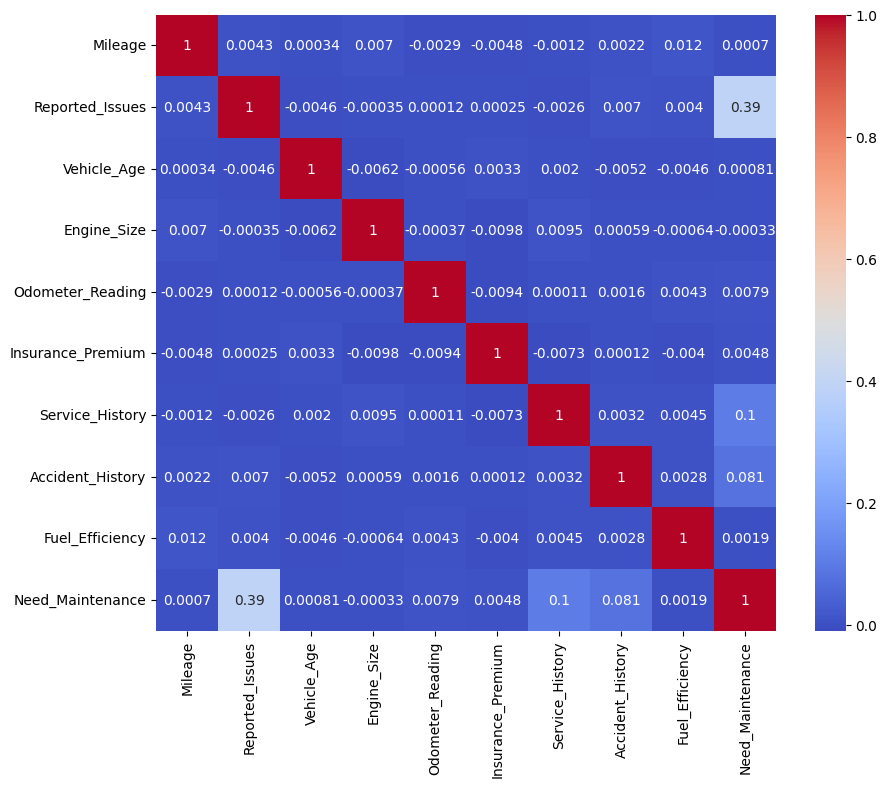

In [28]:
plt.figure(figsize=(10,8))

sns.heatmap(

df[numerical_columns+["Need_Maintenance"]].corr(),

annot=True,

cmap="coolwarm"

)

plt.show()

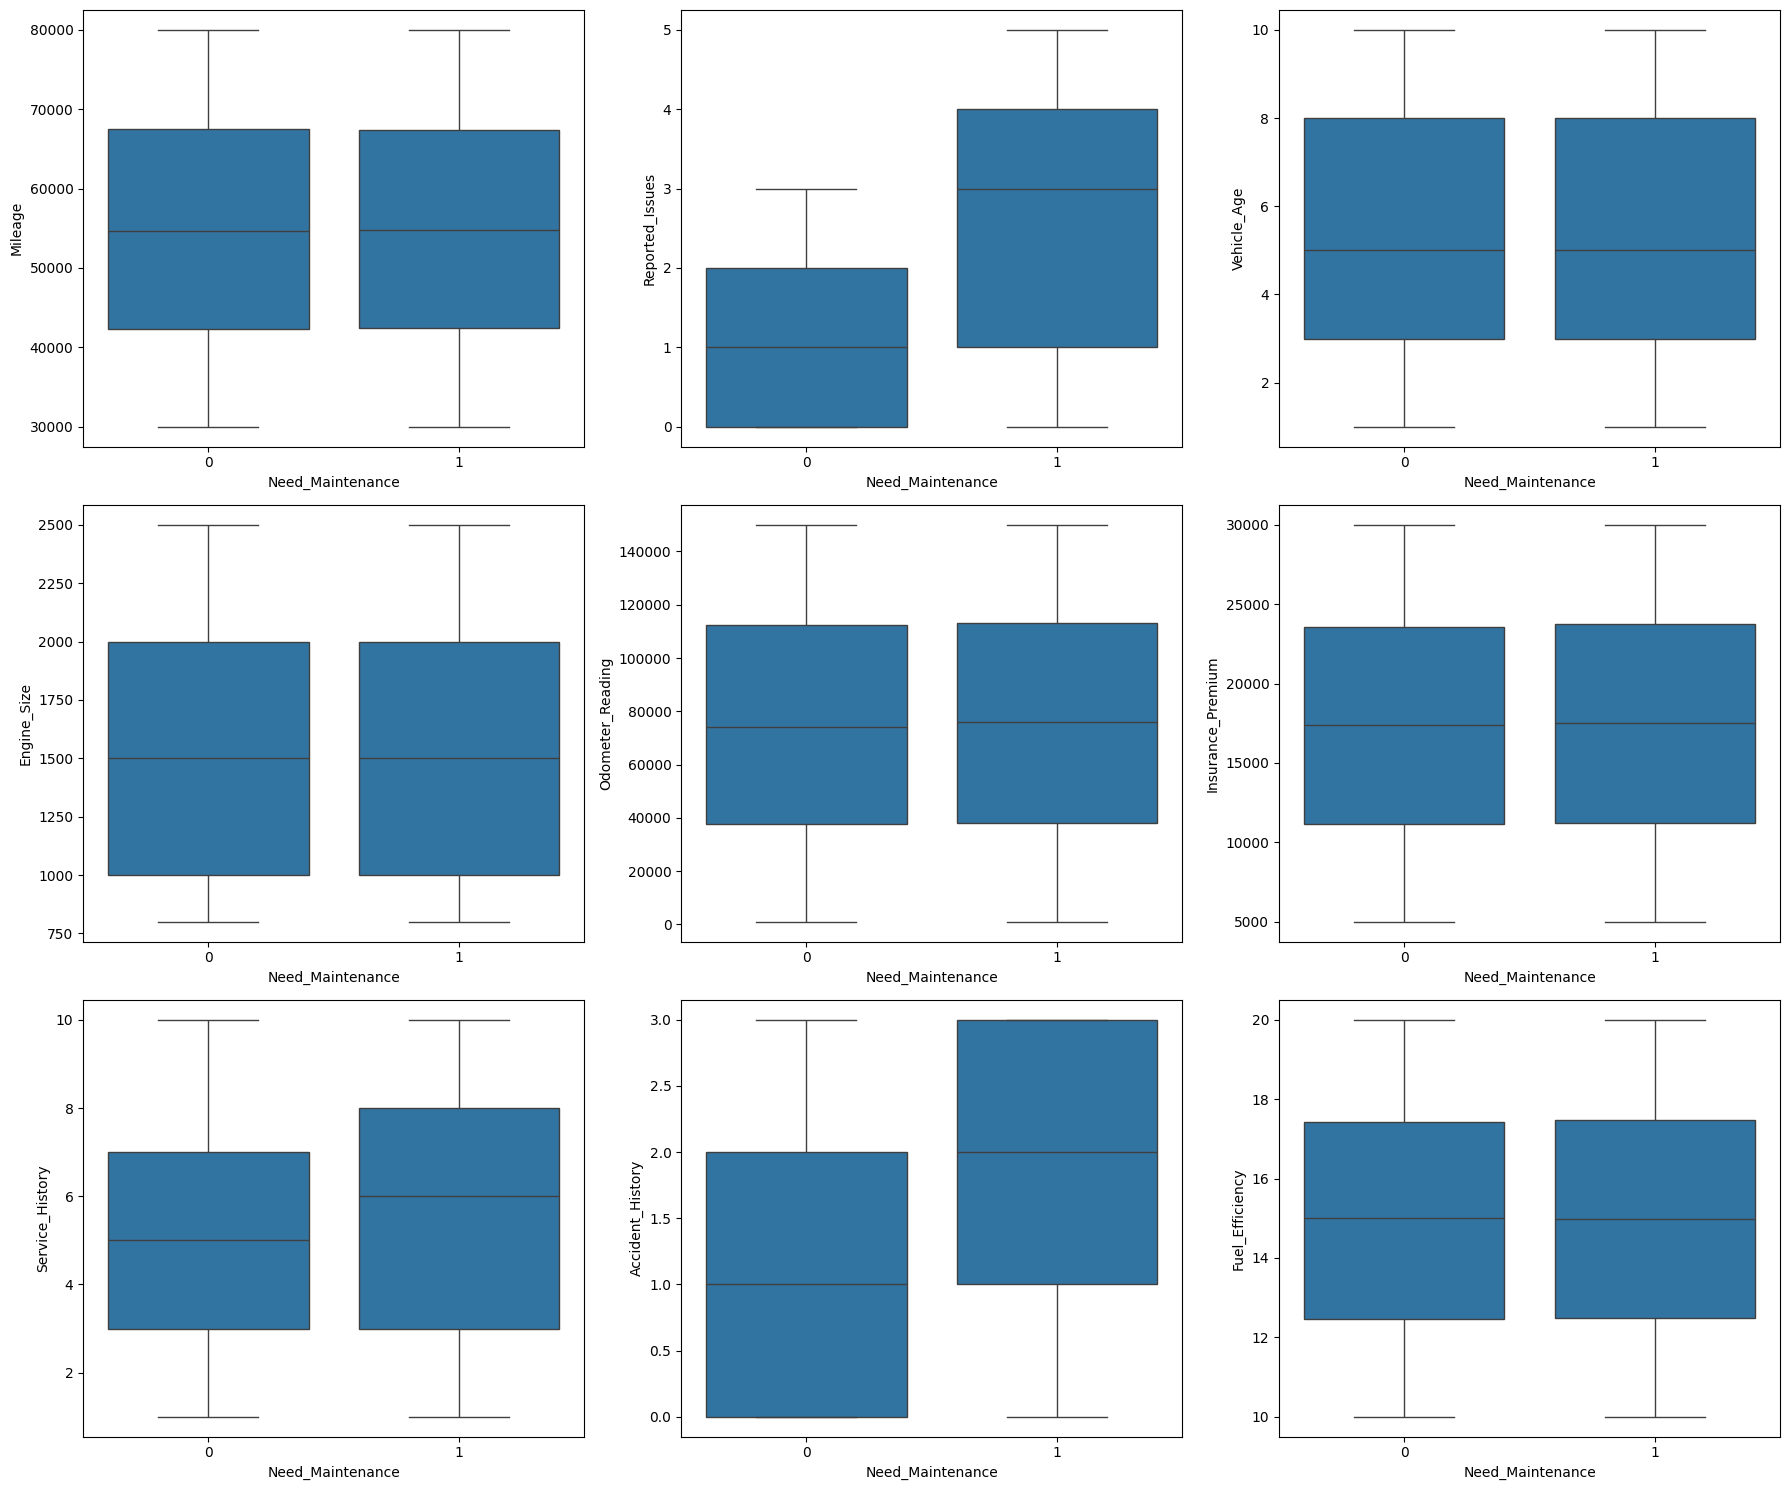

In [29]:
plt.figure(figsize=(18,15))

for i,column in enumerate(numerical_columns):

    plt.subplot(3,3,i+1)

    sns.boxplot(

        x="Need_Maintenance",

        y=column,

        data=df

    )

plt.tight_layout()

plt.show()

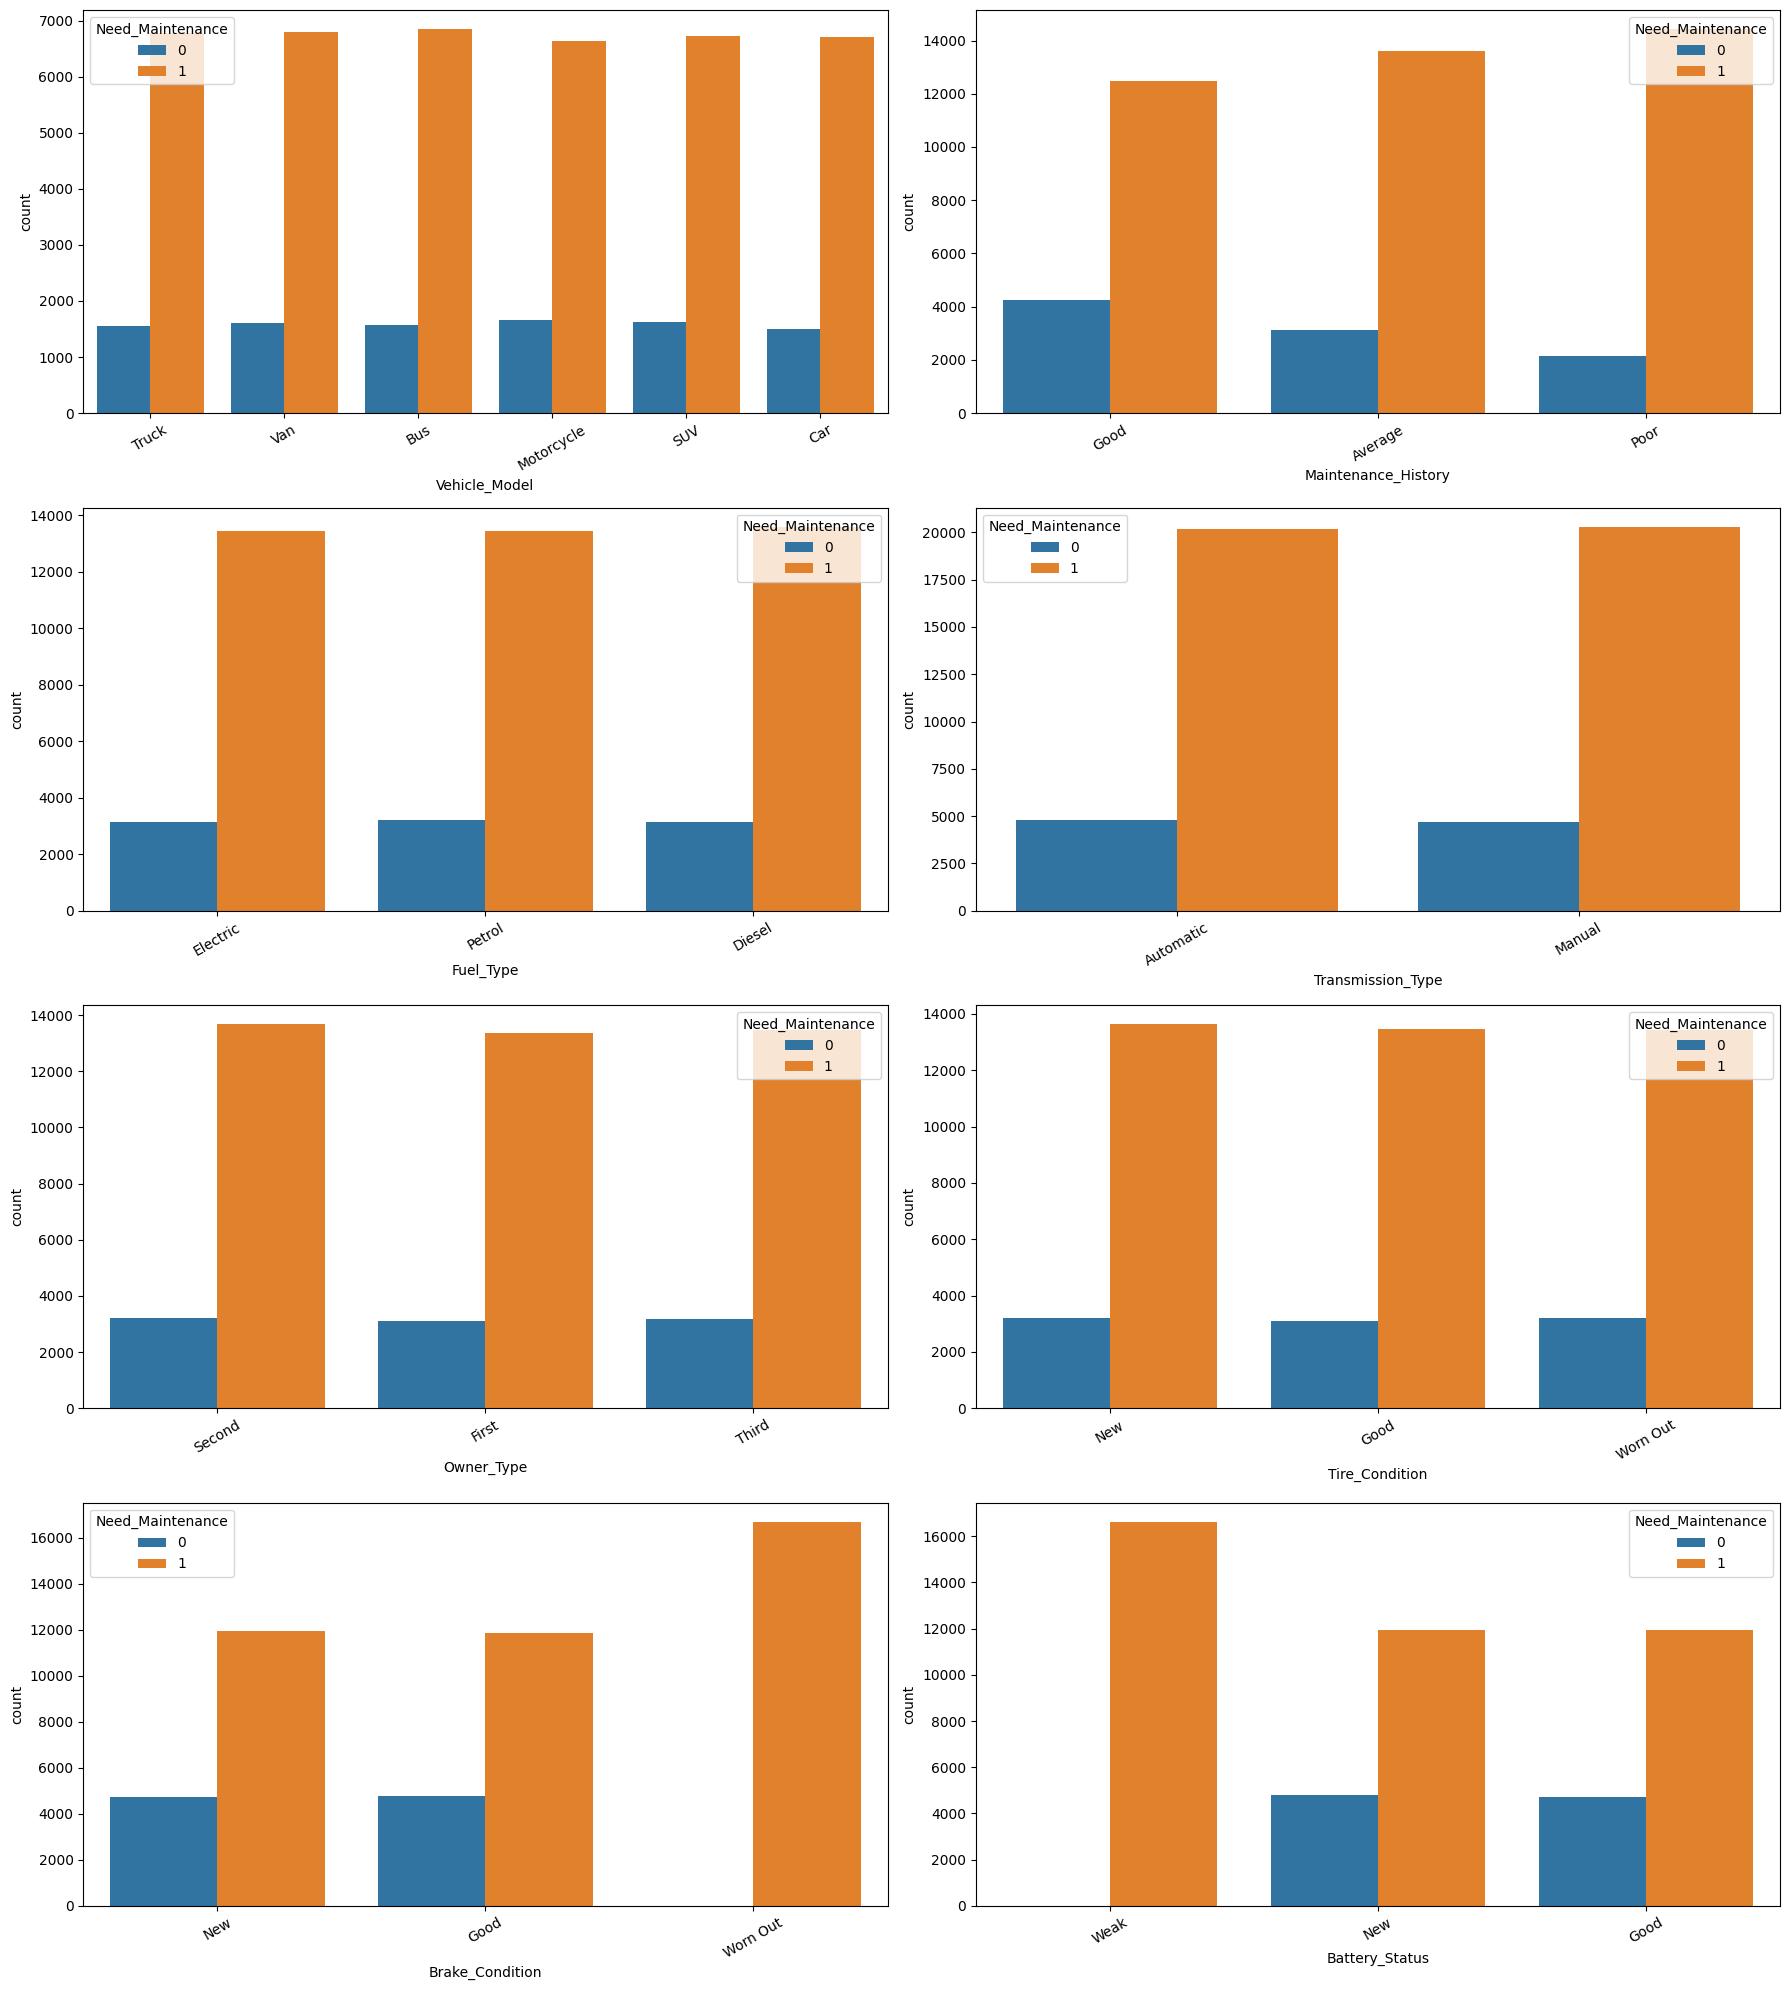

In [30]:
plt.figure(figsize=(18,20))

for i,column in enumerate(categorical_columns):

    plt.subplot(4,2,i+1)

    sns.countplot(

        data=df,

        x=column,

        hue="Need_Maintenance"

    )

    plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [31]:
df["Last_Service_Date"] = pd.to_datetime(df["Last_Service_Date"])

df["Warranty_Expiry_Date"] = pd.to_datetime(df["Warranty_Expiry_Date"])

In [32]:
df[["Last_Service_Date","Warranty_Expiry_Date"]].head()

,Last_Service_Date,Warranty_Expiry_Date
0,2023-11-23,2025-06-24
1,2023-09-21,2025-06-04
2,2023-06-27,2025-04-27
3,2023-08-24,2025-11-05
4,2023-05-25,2025-09-14


#Data Preprocessing

In [33]:
# Verify Missing Values and Duplicates

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Missing Values:
Vehicle_Model           0
Mileage                 0
Maintenance_History     0
Reported_Issues         0
Vehicle_Age             0
Fuel_Type               0
Transmission_Type       0
Engine_Size             0
Odometer_Reading        0
Last_Service_Date       0
Warranty_Expiry_Date    0
Owner_Type              0
Insurance_Premium       0
Service_History         0
Accident_History        0
Fuel_Efficiency         0
Tire_Condition          0
Brake_Condition         0
Battery_Status          0
Need_Maintenance        0
dtype: int64

Duplicate Records:
0


In [34]:
# Convert Date Columns

df["Last_Service_Date"] = pd.to_datetime(df["Last_Service_Date"])
df["Warranty_Expiry_Date"] = pd.to_datetime(df["Warranty_Expiry_Date"])

In [35]:
print(df[["Last_Service_Date", "Warranty_Expiry_Date"]].dtypes)

Last_Service_Date       datetime64[ns]
Warranty_Expiry_Date    datetime64[ns]
dtype: object


In [36]:
# Current Date

today = pd.Timestamp.today()

In [37]:
df["Days_Since_Last_Service"] = (
    today - df["Last_Service_Date"]
).dt.days

In [38]:
df["Warranty_Expired"] = (
    df["Warranty_Expiry_Date"] < today
).astype(int)

In [39]:
df[
    [
        "Last_Service_Date",
        "Warranty_Expiry_Date",
        "Days_Since_Last_Service",
        "Warranty_Expired"
    ]
].head()

,Last_Service_Date,Warranty_Expiry_Date,Days_Since_Last_Service,Warranty_Expired
0,2023-11-23,2025-06-24,966,1
1,2023-09-21,2025-06-04,1029,1
2,2023-06-27,2025-04-27,1115,1
3,2023-08-24,2025-11-05,1057,1
4,2023-05-25,2025-09-14,1148,1


In [40]:
df.drop(
    columns=[
        "Last_Service_Date",
        "Warranty_Expiry_Date"
    ],
    inplace=True
)

In [41]:
df.columns

Index(['Vehicle_Model', 'Mileage', 'Maintenance_History', 'Reported_Issues',
       'Vehicle_Age', 'Fuel_Type', 'Transmission_Type', 'Engine_Size',
       'Odometer_Reading', 'Owner_Type', 'Insurance_Premium',
       'Service_History', 'Accident_History', 'Fuel_Efficiency',
       'Tire_Condition', 'Brake_Condition', 'Battery_Status',
       'Need_Maintenance', 'Days_Since_Last_Service', 'Warranty_Expired'],
      dtype='object')

In [42]:
maintenance_map = {
    "Poor": 0,
    "Average": 1,
    "Good": 2
}

condition_map = {
    "Worn Out": 0,
    "Good": 1,
    "New": 2
}

battery_map = {
    "Weak": 0,
    "Good": 1,
    "New": 2
}

owner_map = {
    "Third": 0,
    "Second": 1,
    "First": 2
}

In [43]:
df["Maintenance_History"] = df["Maintenance_History"].map(maintenance_map)

df["Tire_Condition"] = df["Tire_Condition"].map(condition_map)

df["Brake_Condition"] = df["Brake_Condition"].map(condition_map)

df["Battery_Status"] = df["Battery_Status"].map(battery_map)

df["Owner_Type"] = df["Owner_Type"].map(owner_map)

In [44]:
df = pd.get_dummies(
    df,
    columns=[
        "Vehicle_Model",
        "Fuel_Type",
        "Transmission_Type"
    ],
    drop_first=True
)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Mileage                   50000 non-null  int64  
 1   Maintenance_History       50000 non-null  int64  
 2   Reported_Issues           50000 non-null  int64  
 3   Vehicle_Age               50000 non-null  int64  
 4   Engine_Size               50000 non-null  int64  
 5   Odometer_Reading          50000 non-null  int64  
 6   Owner_Type                50000 non-null  int64  
 7   Insurance_Premium         50000 non-null  int64  
 8   Service_History           50000 non-null  int64  
 9   Accident_History          50000 non-null  int64  
 10  Fuel_Efficiency           50000 non-null  float64
 11  Tire_Condition            50000 non-null  int64  
 12  Brake_Condition           50000 non-null  int64  
 13  Battery_Status            50000 non-null  int64  
 14  Need_M

In [46]:
X = df.drop(columns=["Need_Maintenance"])

y = df["Need_Maintenance"]

In [47]:
print("Feature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)

Feature Matrix Shape: (50000, 24)
Target Shape: (50000,)


In [48]:
X.head()

,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Engine_Size,Odometer_Reading,Owner_Type,Insurance_Premium,Service_History,Accident_History,...,Days_Since_Last_Service,Warranty_Expired,Vehicle_Model_Car,Vehicle_Model_Motorcycle,Vehicle_Model_SUV,Vehicle_Model_Truck,Vehicle_Model_Van,Fuel_Type_Electric,Fuel_Type_Petrol,Transmission_Type_Manual
0,58765,2,0,4,2000,28524,1,20782,6,3,...,966,1,False,False,False,True,False,True,False,False
1,60353,1,1,7,2500,133630,1,23489,7,0,...,1029,1,False,False,False,False,True,True,False,False
2,68072,0,0,2,1500,34022,2,17979,7,0,...,1115,1,False,False,False,False,False,True,False,False
3,60849,1,4,5,2500,81636,1,6220,7,3,...,1057,1,False,False,False,False,False,False,True,False
4,45742,0,5,1,2000,97162,0,16446,6,2,...,1148,1,False,False,False,False,False,False,True,True


In [49]:
y.head()

,Need_Maintenance
0,1
1,1
2,1
3,1
4,1


In [50]:
print("Target Classes:")

print(y.value_counts())

Target Classes:
Need_Maintenance
1    40498
0     9502
Name: count, dtype: int64


#Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [53]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (40000, 24)
Testing Features  : (10000, 24)
Training Target   : (40000,)
Testing Target    : (10000,)


In [54]:
print("Training Set Distribution")
print(y_train.value_counts())

print("\nTesting Set Distribution")
print(y_test.value_counts())

Training Set Distribution
Need_Maintenance
1    32398
0     7602
Name: count, dtype: int64

Testing Set Distribution
Need_Maintenance
1    8100
0    1900
Name: count, dtype: int64


In [55]:
print("Training Set (%)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Set (%)")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Set (%)
Need_Maintenance
1    80.99
0    19.00
Name: proportion, dtype: float64

Testing Set (%)
Need_Maintenance
1    81.0
0    19.0
Name: proportion, dtype: float64


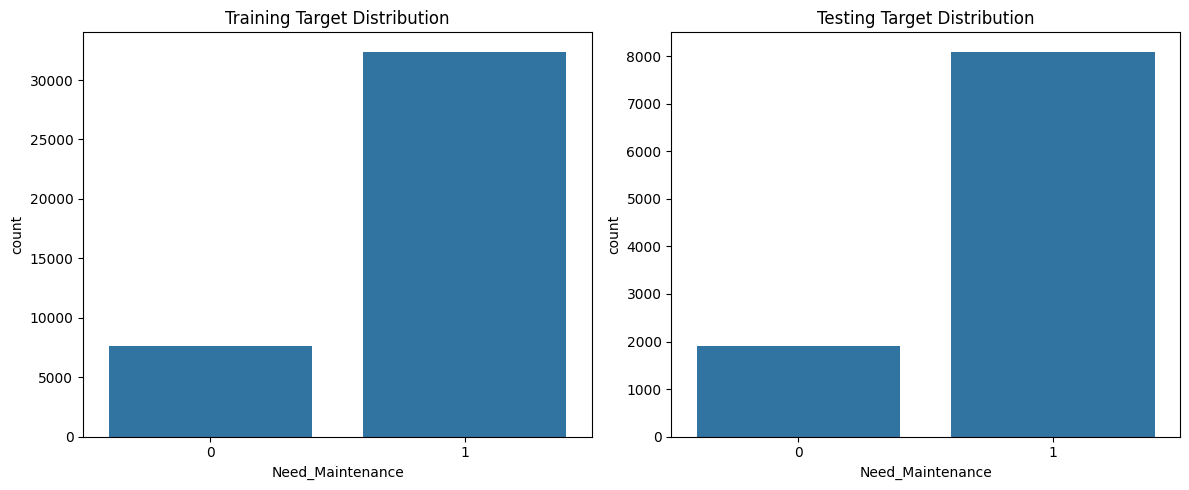

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title("Training Target Distribution")
ax[0].set_xlabel("Need_Maintenance")

sns.countplot(x=y_test, ax=ax[1])
ax[1].set_title("Testing Target Distribution")
ax[1].set_xlabel("Need_Maintenance")

plt.tight_layout()
plt.show()

#Handle Class Imbalance using SMOTE

In [57]:
!pip install imbalanced-learn -q

In [58]:
# Import SMOTE

from imblearn.over_sampling import SMOTE

In [59]:
print("Training Class Distribution (Before SMOTE)")

print(y_train.value_counts())

Training Class Distribution (Before SMOTE)
Need_Maintenance
1    32398
0     7602
Name: count, dtype: int64


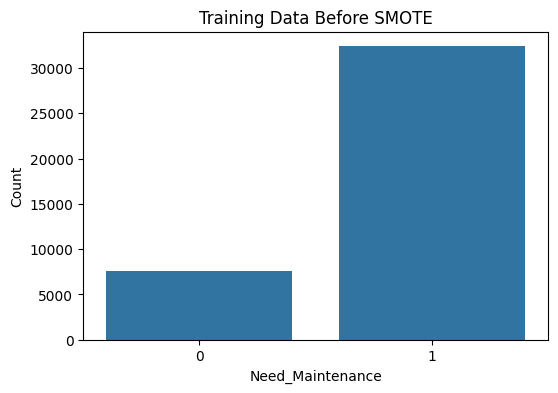

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=y_train)

plt.title("Training Data Before SMOTE")

plt.xlabel("Need_Maintenance")

plt.ylabel("Count")

plt.show()

In [61]:
# Apply SMOTE
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [62]:
print("Original Training Shape")

print(X_train.shape)

print(y_train.shape)

print()

print("After SMOTE")

print(X_train_smote.shape)

print(y_train_smote.shape)

Original Training Shape
(40000, 24)
(40000,)

After SMOTE
(64796, 24)
(64796,)


In [63]:
print("Training Class Distribution (After SMOTE)")

print(y_train_smote.value_counts())

Training Class Distribution (After SMOTE)
Need_Maintenance
1    32398
0    32398
Name: count, dtype: int64


In [64]:
print(
    (
        y_train_smote
        .value_counts(normalize=True)
        *100
    ).round(2)
)

Need_Maintenance
1    50.0
0    50.0
Name: proportion, dtype: float64


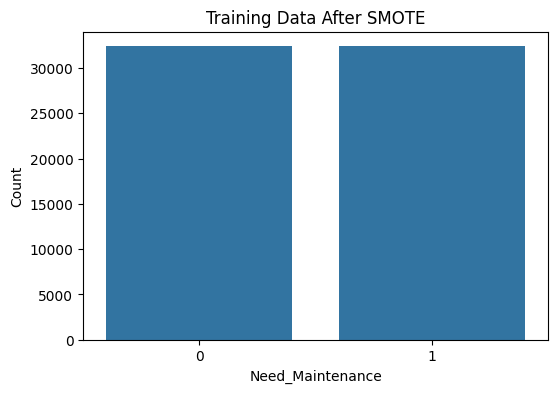

In [65]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("Training Data After SMOTE")

plt.xlabel("Need_Maintenance")

plt.ylabel("Count")

plt.show()

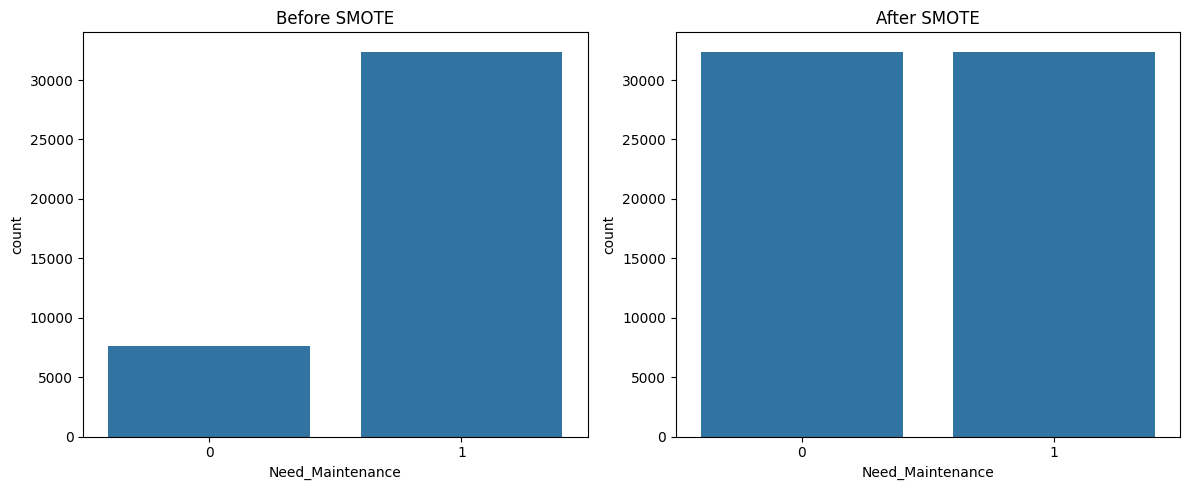

In [66]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

sns.countplot(
    x=y_train,
    ax=ax[0]
)

ax[0].set_title("Before SMOTE")

sns.countplot(
    x=y_train_smote,
    ax=ax[1]
)

ax[1].set_title("After SMOTE")

plt.tight_layout()

plt.show()

#XGBoost Model Training

In [67]:
!pip install xgboost -q

In [68]:
from xgboost import XGBClassifier

In [69]:
# Create XGBoost Model

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [70]:
# Train XGBoost Model
xgb_model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [71]:
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [72]:
print(xgb_model.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


#Model evaluation

In [73]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [74]:

# Predictions

y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:,1]

In [75]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

In [76]:
print("="*45)
print("XGBoost Model Evaluation")
print("="*45)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

XGBoost Model Evaluation
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [77]:
print("\nClassification Report\n")

print(classification_report(y_test, y_pred))


Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00      8100

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



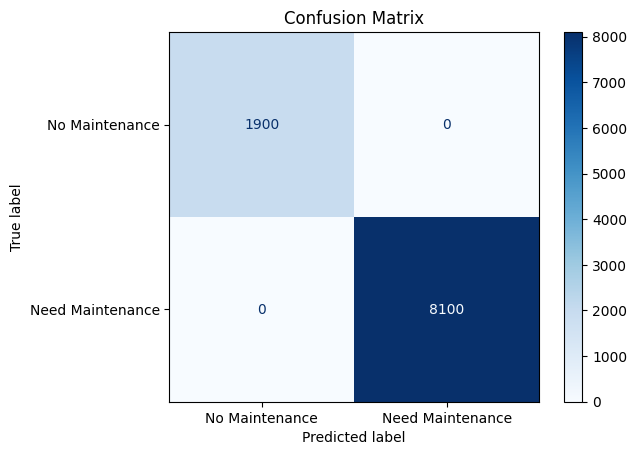

In [78]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Maintenance", "Need Maintenance"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

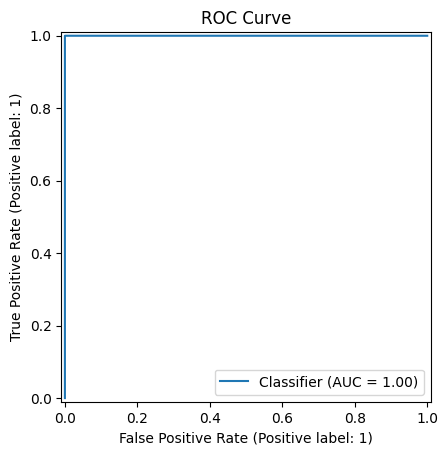

In [79]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")

plt.show()

In [80]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": xgb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
12,Brake_Condition,0.316319
13,Battery_Status,0.283435
2,Reported_Issues,0.239851
1,Maintenance_History,0.058846
9,Accident_History,0.058595
8,Service_History,0.033322
16,Vehicle_Model_Car,0.001421
5,Odometer_Reading,0.001012
0,Mileage,0.000948
23,Transmission_Type_Manual,0.000893


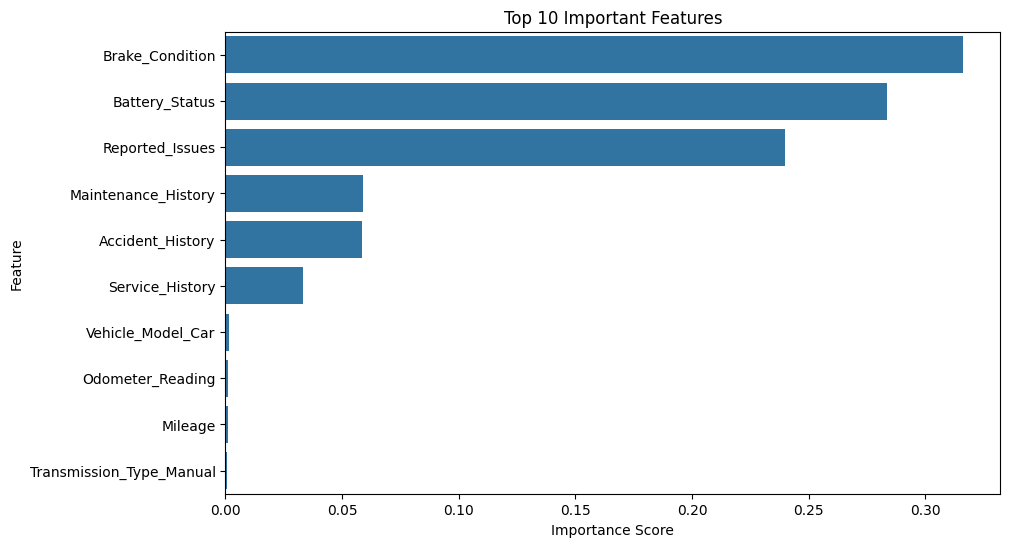

In [81]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=feature_importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.show()

In [82]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                     Feature  Importance
12           Brake_Condition    0.316319
13            Battery_Status    0.283435
2            Reported_Issues    0.239851
1        Maintenance_History    0.058846
9           Accident_History    0.058595
8            Service_History    0.033322
16         Vehicle_Model_Car    0.001421
5           Odometer_Reading    0.001012
0                    Mileage    0.000948
23  Transmission_Type_Manual    0.000893
20         Vehicle_Model_Van    0.000871
4                Engine_Size    0.000683
11            Tire_Condition    0.000679
14   Days_Since_Last_Service    0.000642
7          Insurance_Premium    0.000590


# Phase 8: Random Forest Model

In [83]:
from sklearn.ensemble import RandomForestClassifier

In [84]:
# Create Random Forest Model

rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=10,

    random_state=42,

    n_jobs=-1

)

In [85]:
# Train Random Forest
rf_model.fit(

    X_train_smote,

    y_train_smote

)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [86]:
# Predictions
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [87]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

rf_auc = roc_auc_score(y_test, rf_prob)

In [88]:
print("="*45)

print("Random Forest Evaluation")

print("="*45)

print(f"Accuracy : {rf_accuracy:.4f}")

print(f"Precision: {rf_precision:.4f}")

print(f"Recall   : {rf_recall:.4f}")

print(f"F1 Score : {rf_f1:.4f}")

print(f"ROC-AUC  : {rf_auc:.4f}")

Random Forest Evaluation
Accuracy : 0.9786
Precision: 0.9894
Recall   : 0.9841
F1 Score : 0.9868
ROC-AUC  : 0.9983


In [89]:
from sklearn.metrics import classification_report

print(classification_report(

    y_test,

    rf_pred

))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94      1900
           1       0.99      0.98      0.99      8100

    accuracy                           0.98     10000
   macro avg       0.96      0.97      0.97     10000
weighted avg       0.98      0.98      0.98     10000



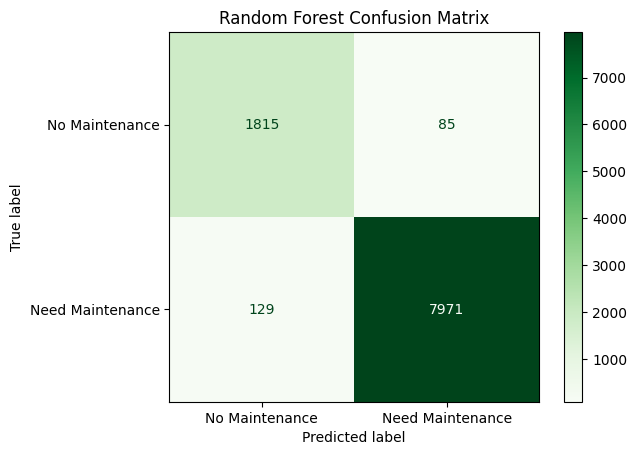

In [90]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(

    y_test,

    rf_pred,

    display_labels=[

        "No Maintenance",

        "Need Maintenance"

    ],

    cmap="Greens"

)

plt.title("Random Forest Confusion Matrix")

plt.show()

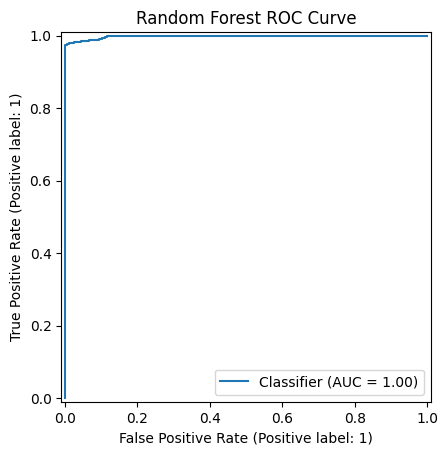

In [91]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(

    y_test,

    rf_prob

)

plt.title("Random Forest ROC Curve")

plt.show()

In [92]:
rf_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

rf_importance = rf_importance.sort_values(

    by="Importance",

    ascending=False

)

rf_importance.head(10)

,Feature,Importance
2,Reported_Issues,0.344456
13,Battery_Status,0.223761
12,Brake_Condition,0.221707
8,Service_History,0.051736
9,Accident_History,0.047926
1,Maintenance_History,0.022021
11,Tire_Condition,0.013263
4,Engine_Size,0.012910
6,Owner_Type,0.011454
23,Transmission_Type_Manual,0.010146


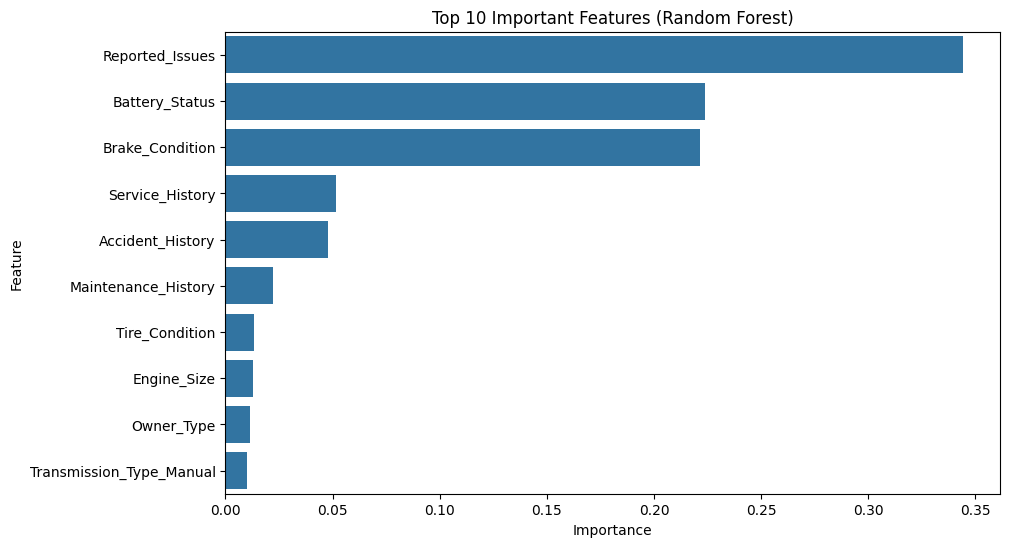

In [93]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=rf_importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features (Random Forest)")

plt.show()

# Phase 9: Model Comparison

In [94]:
# Model Comparison Table

comparison = pd.DataFrame({

    "Model": ["XGBoost", "Random Forest"],

    "Accuracy": [accuracy, rf_accuracy],

    "Precision": [precision, rf_precision],

    "Recall": [recall, rf_recall],

    "F1 Score": [f1, rf_f1],

    "ROC-AUC": [roc_auc, rf_auc]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,1.0000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,0.9786,0.989449,0.984074,0.986754,0.998324


In [95]:
comparison = comparison.round(4)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,0.9786,0.9894,0.9841,0.9868,0.9983


In [96]:
comparison.style.highlight_max(
    color="lightgreen"
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,0.978600,0.989400,0.984100,0.986800,0.998300


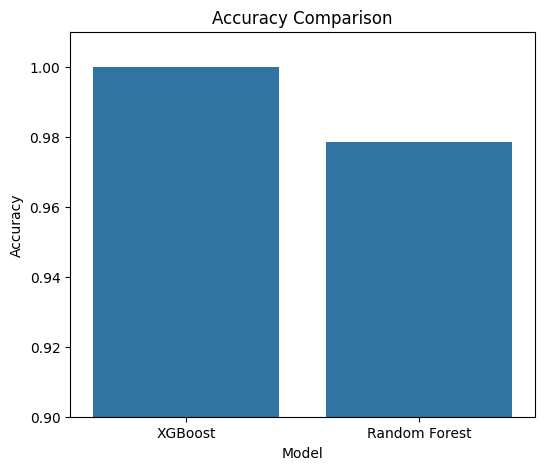

In [97]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")

plt.ylim(0.90,1.01)

plt.show()

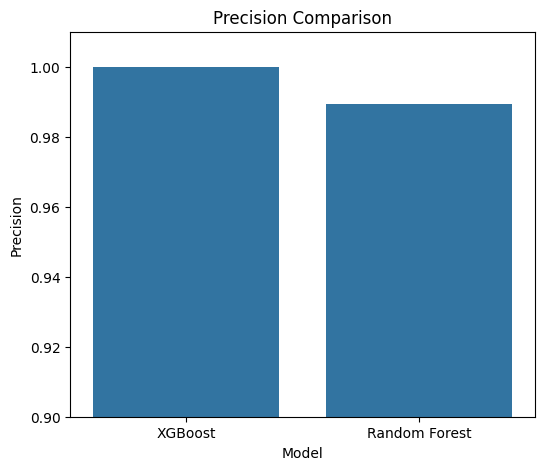

In [98]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison")

plt.ylim(0.90,1.01)

plt.show()

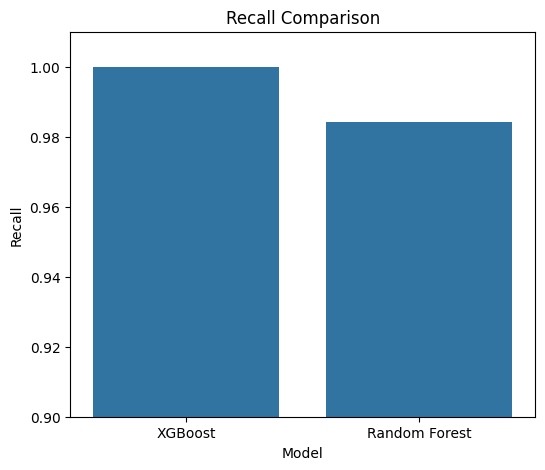

In [99]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Recall"
)

plt.title("Recall Comparison")

plt.ylim(0.90,1.01)

plt.show()

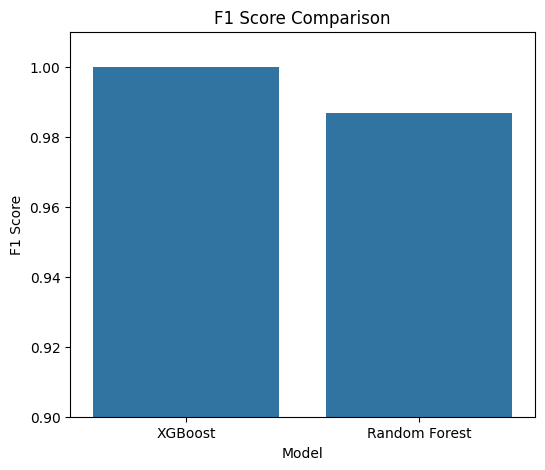

In [100]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison")

plt.ylim(0.90,1.01)

plt.show()

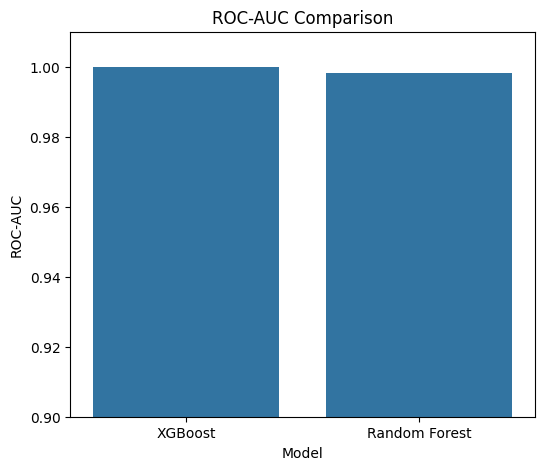

In [101]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison")

plt.ylim(0.90,1.01)

plt.show()

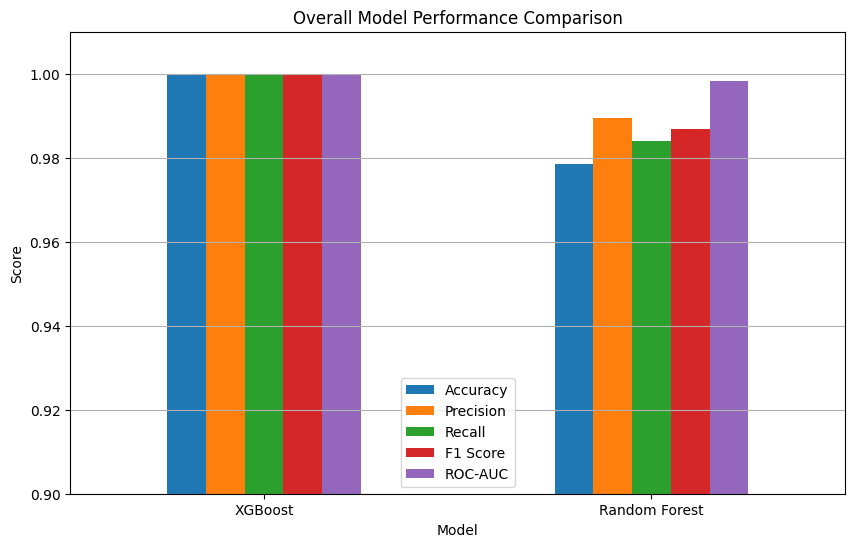

In [102]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Overall Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0.90,1.01)

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [103]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

print("Best Model:", best_model)

Best Model: XGBoost


In [104]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Comparison table saved successfully.")

Comparison table saved successfully.


#Explainable AI using SHAP

In [105]:
!pip install shap -q

In [106]:
import shap

In [107]:
# Create SHAP Explainer

explainer = shap.TreeExplainer(xgb_model)

In [108]:
# Calculate SHAP Values
X_sample = X_test.iloc[:100]

shap_values = explainer.shap_values(X_sample)

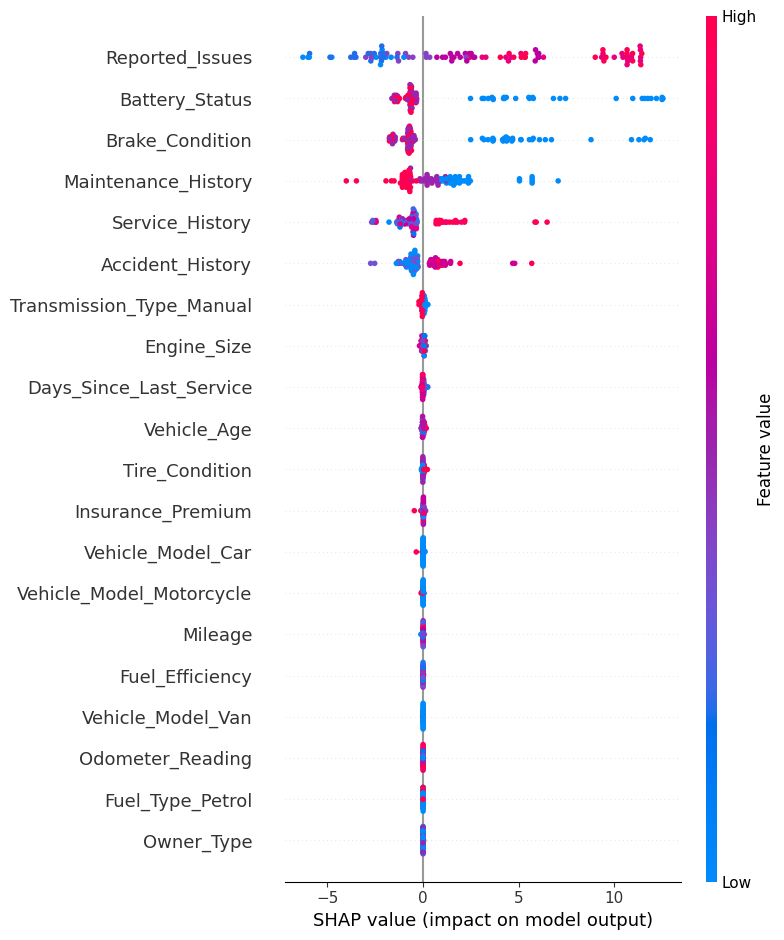

In [109]:
shap.summary_plot(
    shap_values,
    X_sample
)

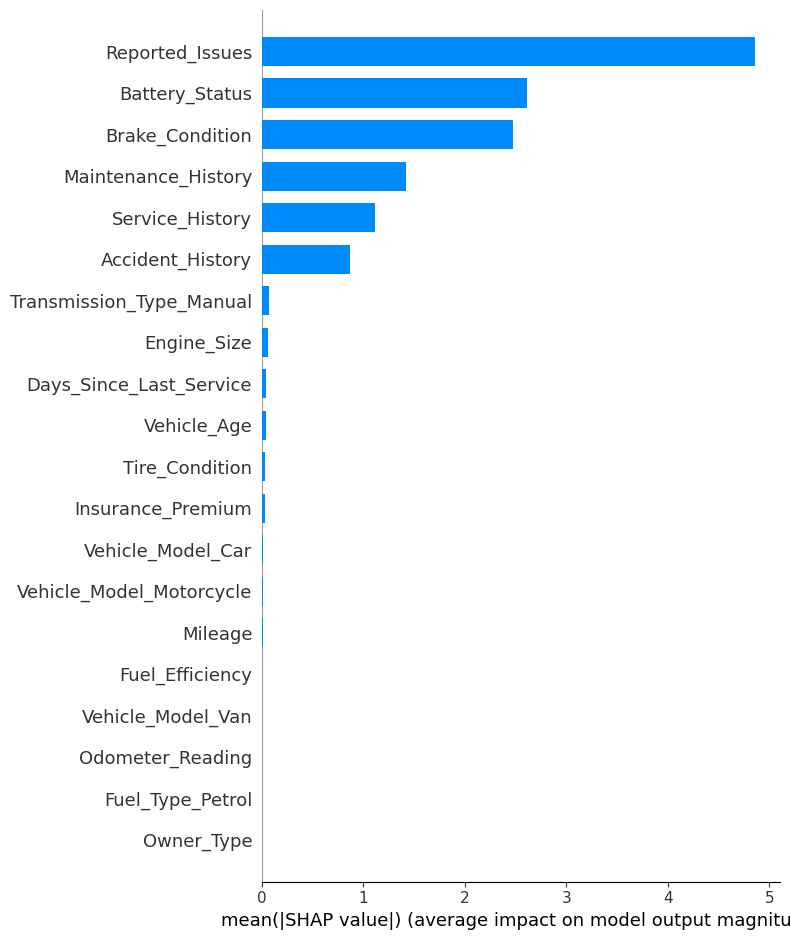

In [110]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

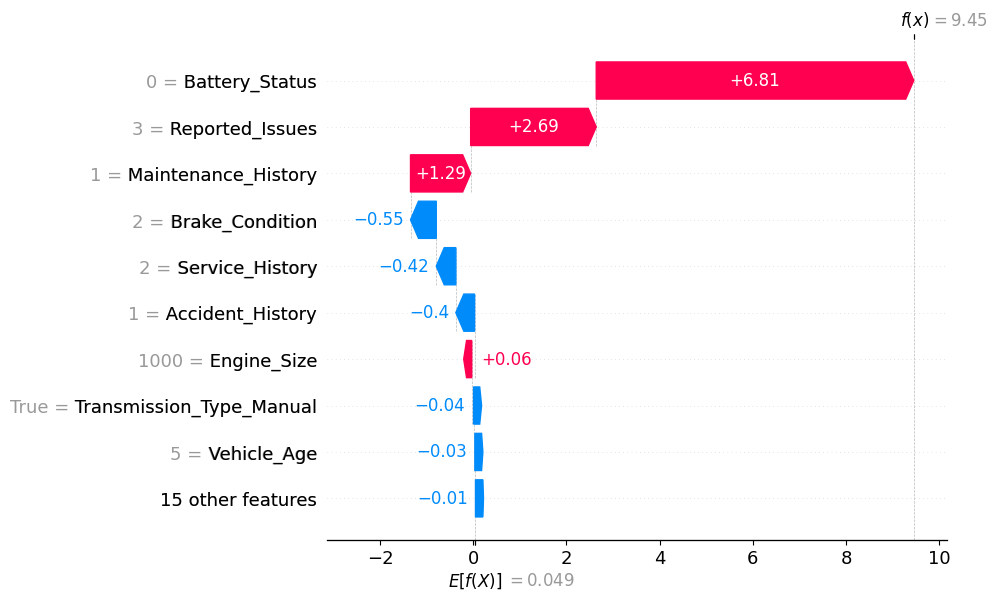

In [111]:
vehicle_index = 0

shap.plots.waterfall(
    explainer(
        X_sample.iloc[[vehicle_index]]
    )[0]
)

In [112]:
shap.initjs()

shap.force_plot(

    explainer.expected_value,

    shap_values[0],

    X_sample.iloc[0]

)

#Vehicle Health Score

In [113]:
maintenance_probability = xgb_model.predict_proba(X_test)[:,1]

In [114]:
# Vehicle Health Score
health_score = (1 - maintenance_probability) * 100

In [115]:
health_score = health_score.round(2)

In [116]:
health_df = pd.DataFrame({

    "Prediction": y_pred,

    "Maintenance Probability (%)":
        (maintenance_probability*100).round(2),

    "Vehicle Health Score":
        health_score

})

health_df.head(10)

,Prediction,Maintenance Probability (%),Vehicle Health Score
0,1,99.989998,0.010000
1,0,0.120000,99.879997
2,1,99.970001,0.030000
3,1,99.980003,0.020000
4,1,99.889999,0.110000
5,1,99.980003,0.020000
6,1,99.989998,0.010000
7,0,0.010000,99.989998
8,1,99.989998,0.010000
9,1,99.989998,0.010000


In [117]:
def health_status(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Fair"

    elif score >= 20:
        return "Poor"

    else:
        return "Critical"

In [118]:
health_df["Health Status"] = health_df[
    "Vehicle Health Score"
].apply(health_status)

In [119]:
health_df.head(10)

,Prediction,Maintenance Probability (%),Vehicle Health Score,Health Status
0,1,99.989998,0.010000,Critical
1,0,0.120000,99.879997,Excellent
2,1,99.970001,0.030000,Critical
3,1,99.980003,0.020000,Critical
4,1,99.889999,0.110000,Critical
5,1,99.980003,0.020000,Critical
6,1,99.989998,0.010000,Critical
7,0,0.010000,99.989998,Excellent
8,1,99.989998,0.010000,Critical
9,1,99.989998,0.010000,Critical


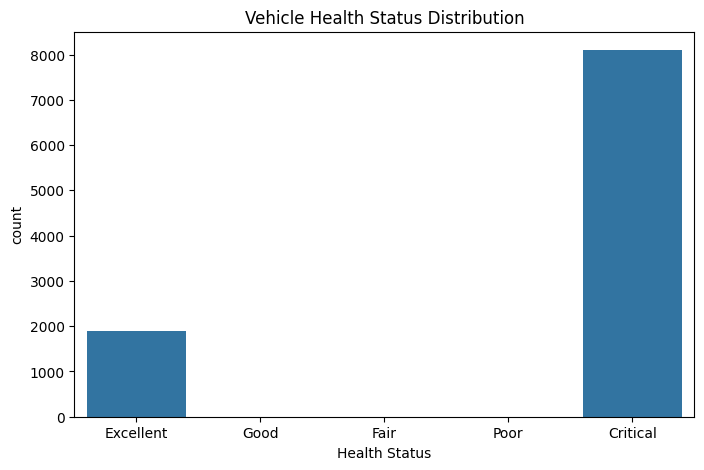

In [120]:
plt.figure(figsize=(8,5))

sns.countplot(

    data=health_df,

    x="Health Status",

    order=[

        "Excellent",

        "Good",

        "Fair",

        "Poor",

        "Critical"

    ]

)

plt.title("Vehicle Health Status Distribution")

plt.show()

In [121]:
health_df.describe()

,Prediction,Maintenance Probability (%),Vehicle Health Score
count,10000.000000,10000.000000,10000.000000
mean,0.810000,80.969055,19.030939
std,0.392321,39.188175,39.188084
min,0.000000,0.000000,0.000000
25%,1.000000,99.889999,0.010000
50%,1.000000,99.989998,0.010000
75%,1.000000,99.989998,0.110000
max,1.000000,100.000000,100.000000


In [122]:
importance_table = feature_importance.copy()

importance_table["Importance (%)"] = (
    importance_table["Importance"]
    / importance_table["Importance"].sum()
    *100
)

importance_table.head(10)

,Feature,Importance,Importance (%)
12,Brake_Condition,0.316319,31.631943
13,Battery_Status,0.283435,28.343483
2,Reported_Issues,0.239851,23.985056
1,Maintenance_History,0.058846,5.884563
9,Accident_History,0.058595,5.859455
8,Service_History,0.033322,3.332230
16,Vehicle_Model_Car,0.001421,0.142116
5,Odometer_Reading,0.001012,0.101219
0,Mileage,0.000948,0.094758
23,Transmission_Type_Manual,0.000893,0.089282


In [123]:
plt.savefig("shap_summary.png", dpi=300)

<Figure size 640x480 with 0 Axes>

#CatBoost Model Training & Evaluation

In [124]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [125]:
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [126]:
cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_train_smote,
    y_train_smote
)

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.1, random_seed=42, verbose=0)

In [127]:
y_pred_cat = cat_model.predict(X_test)

y_prob_cat = cat_model.predict_proba(X_test)[:,1]

In [128]:
accuracy_cat = accuracy_score(y_test, y_pred_cat)

precision_cat = precision_score(y_test, y_pred_cat)

recall_cat = recall_score(y_test, y_pred_cat)

f1_cat = f1_score(y_test, y_pred_cat)

roc_auc_cat = roc_auc_score(y_test, y_prob_cat)

print("CatBoost Performance")
print("-------------------------")

print(f"Accuracy : {accuracy_cat:.4f}")
print(f"Precision: {precision_cat:.4f}")
print(f"Recall   : {recall_cat:.4f}")
print(f"F1 Score : {f1_cat:.4f}")
print(f"ROC-AUC  : {roc_auc_cat:.4f}")

CatBoost Performance
-------------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [129]:
print(classification_report(
    y_test,
    y_pred_cat
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1900
           1       1.00      1.00      1.00      8100

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



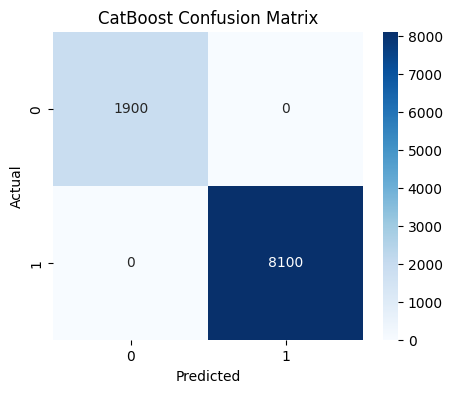

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_cat),
    annot=True,
    fmt='d',
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("CatBoost Confusion Matrix")

plt.show()

In [131]:
comparison.loc[len(comparison)] = [
    "CatBoost",
    accuracy_cat,
    precision_cat,
    recall_cat,
    f1_cat,
    roc_auc_cat
]

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000
1,Random Forest,0.9786,0.9894,0.9841,0.9868,0.9983
2,CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000
